# Name: Papia Karjee
# Email:karjeepapia@gmail.com


# Projects : Car Resale Price Analysis & Visualization System 
# Problem Statement: 
You are a data analyst working for a car dealership. You have received a CSV file containing sales data. Your goal is to understand the sales pattern, customer behavior, and make visual insights using Python basics, Object-Oriented Programming (OOP), NumPy, Pandas, Matplotlib, and Seaborn.

# job includes:
1.Data cleaning and preprocessing
2.Basic Analysis
3.OOP Implementation
4.Visualization
5.Extracting insights

# importing  necessary libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset

In [13]:
df = pd.read_csv('./data.csv')
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


# Insights:
    Selling price and present price are in lakhs means 3.35 -> 3.35 lakhs

# Shape Inspection

In [15]:
a = df.shape
print(f'Rows:{a[0]}',f'Columns:{a[1]}')

Rows:301 Columns:9


# Data-Types

In [17]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

# Data Information

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


# Insights:
    There is no null values.

In [22]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

# If We have Null values:
  1. Drop the null values.
  2. Fill null values -> Mean, Median, mode, Constant

In [24]:
df.Car_Name.value_counts()

Car_Name
city                        26
corolla altis               16
verna                       14
fortuner                    11
brio                        10
                            ..
Honda CB Trigger             1
Yamaha FZ S                  1
Bajaj Pulsar 135 LS          1
Activa 4g                    1
Bajaj Avenger Street 220     1
Name: count, Length: 98, dtype: int64

In [26]:
df['Car_Name'].unique()

array(['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza',
       's cross', 'alto 800', 'ertiga', 'dzire', 'alto k10', 'ignis',
       '800', 'baleno', 'omni', 'fortuner', 'innova', 'corolla altis',
       'etios cross', 'etios g', 'etios liva', 'corolla', 'etios gd',
       'camry', 'land cruiser', 'Royal Enfield Thunder 500',
       'UM Renegade Mojave', 'KTM RC200', 'Bajaj Dominar 400',
       'Royal Enfield Classic 350', 'KTM RC390', 'Hyosung GT250R',
       'Royal Enfield Thunder 350', 'KTM 390 Duke ',
       'Mahindra Mojo XT300', 'Bajaj Pulsar RS200',
       'Royal Enfield Bullet 350', 'Royal Enfield Classic 500',
       'Bajaj Avenger 220', 'Bajaj Avenger 150', 'Honda CB Hornet 160R',
       'Yamaha FZ S V 2.0', 'Yamaha FZ 16', 'TVS Apache RTR 160',
       'Bajaj Pulsar 150', 'Honda CBR 150', 'Hero Extreme',
       'Bajaj Avenger 220 dtsi', 'Bajaj Avenger 150 street',
       'Yamaha FZ  v 2.0', 'Bajaj Pulsar  NS 200', 'Bajaj Pulsar 220 F',
       'TVS Apache RTR 180', 

In [28]:
df['Car_Name'].nunique() # there are 98 different cars we have in our dataset.

98

# Feature Engineering:
1. Add a New column Age of car

In [30]:
Current_Year = 2025
df['Car_Age'] = Current_Year - df['Year']
df.head(1)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11


In [320]:
pd.Timestamp.now().year #To get the current time

2025

# How depreciation affects the value of a car

In [32]:
df['Depreciation'] = df['Present_Price'] - df['Selling_Price']

# Let's see how wear and tear the car gets based in total km

In [34]:
df['Car_Driven_Per_Year'] = df['Kms_Driven']/df['Car_Age']
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Depreciation,Car_Driven_Per_Year
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,2.24,2454.545455
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,4.79,3583.333333
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,2.60,862.500000
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,1.30,371.428571
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,2.27,3859.090909


# Rename some columns:

In [41]:
df.rename(columns = {
    'Car_Name':'Brand',
    'Present_Price':'Price'
},inplace = True)

In [43]:
df['Price'].unique()

array([ 5.59 ,  9.54 ,  9.85 ,  4.15 ,  6.87 ,  9.83 ,  8.12 ,  8.61 ,
        8.89 ,  8.92 ,  3.6  , 10.38 ,  9.94 ,  7.71 ,  7.21 , 10.79 ,
        5.09 ,  7.98 ,  3.95 ,  5.71 ,  8.01 ,  3.46 ,  4.41 ,  4.99 ,
        5.87 ,  6.49 ,  5.98 ,  4.89 ,  7.49 ,  9.95 ,  8.06 ,  7.74 ,
        7.2  ,  2.28 ,  3.76 ,  7.87 ,  3.98 ,  7.15 ,  2.69 , 12.04 ,
        9.29 , 30.61 , 19.77 , 10.21 , 15.04 ,  7.27 , 18.54 ,  6.8  ,
       35.96 , 18.61 ,  7.7  , 36.23 ,  6.95 , 23.15 , 20.45 , 13.74 ,
       20.91 ,  6.76 , 12.48 ,  8.93 , 14.68 , 12.35 , 22.83 , 14.89 ,
        7.85 , 25.39 , 13.46 , 23.73 , 92.6  ,  6.05 , 16.09 , 13.7  ,
       22.78 , 18.64 ,  1.9  ,  1.82 ,  1.78 ,  1.6  ,  1.47 ,  2.37 ,
        3.45 ,  1.5  ,  2.4  ,  1.4  ,  1.26 ,  1.17 ,  1.75 ,  0.95 ,
        0.8  ,  0.87 ,  0.84 ,  0.82 ,  0.81 ,  0.74 ,  1.2  ,  0.787,
        0.99 ,  0.94 ,  0.826,  0.55 ,  0.88 ,  0.51 ,  0.52 ,  0.54 ,
        0.73 ,  0.83 ,  0.64 ,  0.72 ,  1.05 ,  0.57 ,  0.48 ,  0.58 ,
      

# Numpy implementation:
  Classify price segment using np.where

In [49]:
price_array = df['Price'].values
Price_Segment = np.where(price_array>20,'Luxury','Standard')
df['Segment'] = Price_Segment
df.head(5)

,Brand,Year,Selling_Price,Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Depreciation,Car_Driven_Per_Year,Segment
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,2.24,2454.545455,Standard
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,4.79,3583.333333,Standard
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,2.60,862.500000,Standard
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,1.30,371.428571,Standard
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,2.27,3859.090909,Standard


# Let's see overall Stats value

In [51]:
df.describe()

,Year,Selling_Price,Price,Kms_Driven,Owner,Car_Age,Depreciation,Car_Driven_Per_Year
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189,11.372093,2.967176,3034.762560
std,2.891554,5.082812,8.644115,38886.883882,0.247915,2.891554,4.828771,2437.178310
min,2003.000000,0.100000,0.320000,500.000000,0.000000,7.000000,0.030000,55.555556
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000,9.000000,0.390000,1500.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000,11.000000,1.640000,2760.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000,13.000000,3.350000,4010.153846
max,2018.000000,35.000000,92.600000,500000.000000,3.000000,22.000000,57.600000,29411.764706


In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,301.0,2013.627907,2.891554,2003.000000,2012.00,2014.00,2016.000000,2018.000000
Selling_Price,301.0,4.661296,5.082812,0.100000,0.90,3.60,6.000000,35.000000
Price,301.0,7.628472,8.644115,0.320000,1.20,6.40,9.900000,92.600000
Kms_Driven,301.0,36947.205980,38886.883882,500.000000,15000.00,32000.00,48767.000000,500000.000000
Owner,301.0,0.043189,0.247915,0.000000,0.00,0.00,0.000000,3.000000
Car_Age,301.0,11.372093,2.891554,7.000000,9.00,11.00,13.000000,22.000000
Depreciation,301.0,2.967176,4.828771,0.030000,0.39,1.64,3.350000,57.600000
Car_Driven_Per_Year,301.0,3034.762560,2437.178310,55.555556,1500.00,2760.00,4010.153846,29411.764706


### Insight

  1.Maximum Price of a car is 92 lac ruppes
  2.On an average the year of car we have is 11 years
  3.Approx 3000 km was driven by cars on average in a year
  4.Most of the car had the price less than 10 lack

In [55]:
df.describe(include = 'O').T

,count,unique,top,freq
Brand,301,98,city,26
Fuel_Type,301,3,Petrol,239
Seller_Type,301,2,Dealer,195
Transmission,301,2,Manual,261
Segment,301,2,Standard,282


In [57]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0
Car_Age,301.0,NaN,NaN,NaN,11.372093,2.891554,7.0,9.0,11.0,13.0,22.0


In [59]:
df.describe(include = 'O') # # Include O means we are trying to find stats data for object Data type

,Brand,Fuel_Type,Seller_Type,Transmission,Segment
count,301,301,301,301,301
unique,98,3,2,2,2
top,city,Petrol,Dealer,Manual,Standard
freq,26,239,195,261,282


# Most freequently car we are getting honda city.
# Petrol car are maximum brought
# Mostly manual cars are being preffered.

In [61]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0
Car_Age,301.0,NaN,NaN,NaN,11.372093,2.891554,7.0,9.0,11.0,13.0,22.0


# Let's Use GroupBY method to check brand wise average price

In [63]:
Brand_wise_Average_Price = df.groupby('Brand')['Price'].mean()
Brand_wise_Average_Price 

Brand
800                  2.280000
Activa 3g            0.530000
Activa 4g            0.510000
Bajaj  ct 100        0.320000
Bajaj Avenger 150    0.800000
                       ...   
sx4                  8.066667
verna                9.400000
vitara brezza        9.830000
wagon r              4.450000
xcent                7.130000
Name: Price, Length: 98, dtype: float64

### Visualization(Categorical Visualization)
# Fuel Type

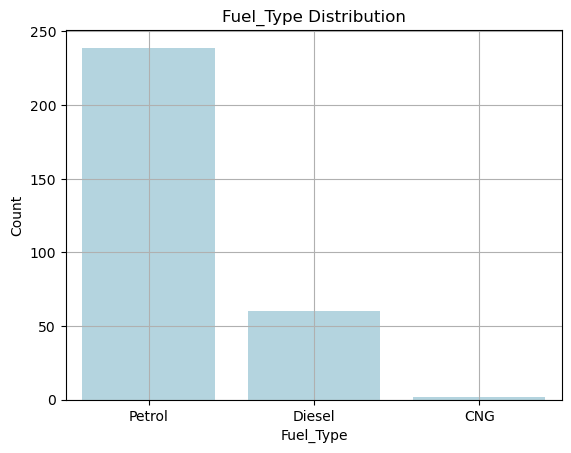

In [65]:
sns.countplot(x = 'Fuel_Type',data = df,color ='lightblue')
plt.xlabel('Fuel_Type')
plt.ylabel('Count')
plt.title('Fuel_Type Distribution')
plt.grid(True)
plt.show()



# Insights:
   1. Petrol is mostly used followed by disel vehicle.
   2. CNG is least preferred fuel type

## Seller type

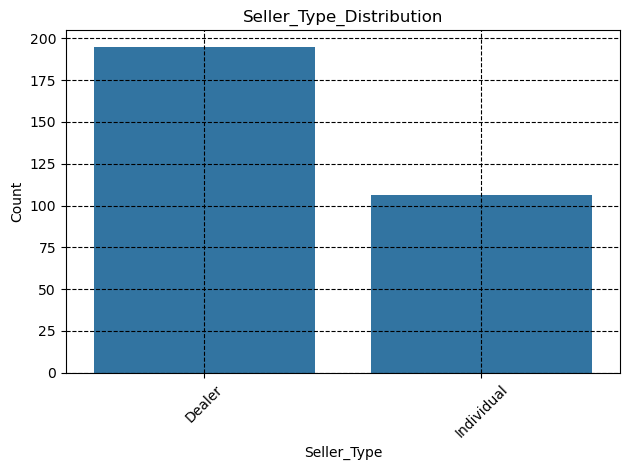

In [67]:
sns.countplot(x = 'Seller_Type',data = df)
plt.xlabel('Seller_Type')
plt.ylabel('Count')
plt.title('Seller_Type_Distribution')
plt.grid(linestyle ='--',color ='black')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# Insights:
    Customers are buying more cars rather than choosing individuals.

### Transmission

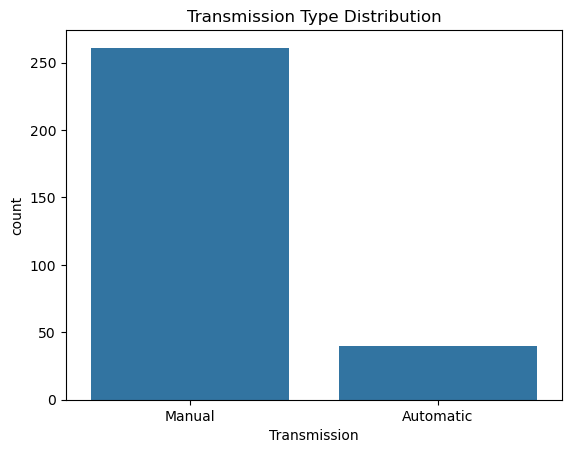

In [71]:
sns.countplot(x = 'Transmission',data = df)
plt.xlabel('Transmission')
plt.title('Transmission Type Distribution')
plt.show()

# Insights:
  1. More manual cars are there in carResale shop
  2. Maybe beacause we have the data where the cars are 11 year old on an average.


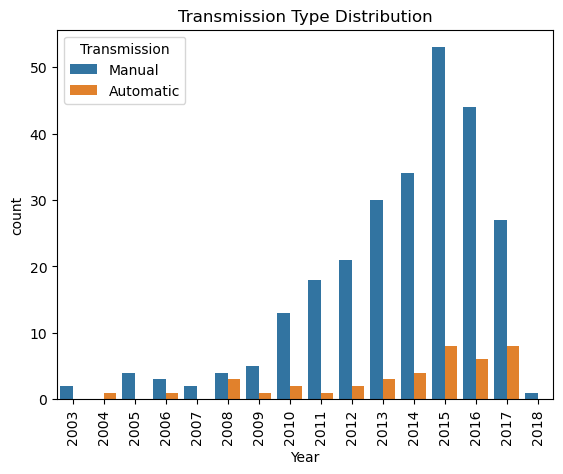

In [73]:
sns.countplot(x = 'Year',hue = 'Transmission',data = df)
plt.title('Transmission Type Distribution')
plt.xticks(rotation = 90)
plt.show()


# Insights: 
  1.Manual cars dominate the dataset,especially between 2010-2015.
  2. Automatic cars appear after 2010 and show a slow increase,but remain fewer than manuals.
  3. The peak year is 2015 for both transmission types.
  4. car counts decline after 2016, likely due to fewer recent entries in the dataset.                       


### Relationship visualization

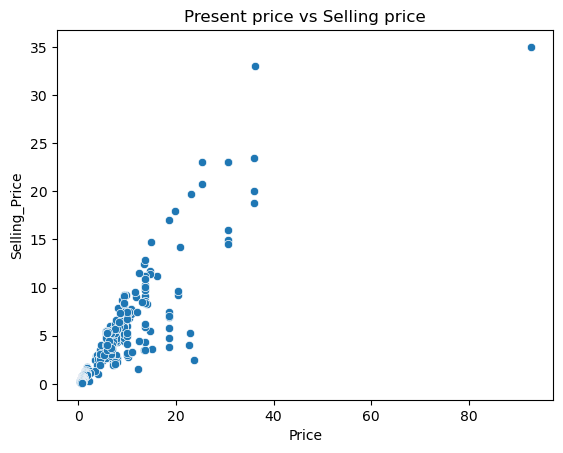

In [75]:
sns.scatterplot(x = 'Price', y = 'Selling_Price',data = df)
plt.xlabel('Price')
plt.ylabel('Selling_Price')
plt.title('Present price vs Selling price')
plt.show()

### Insight

1.higher the present price will be, higher the selling price will be (Positive Trend)
2.Increase is not equal = selling price grows slower at higher present price
3.One or two outliers with very high present price and selling price -> we can remove the outlier -> IQR
4.Most data points are between 0-20 lakhs, that shows the price of car

### kms driven by selling price

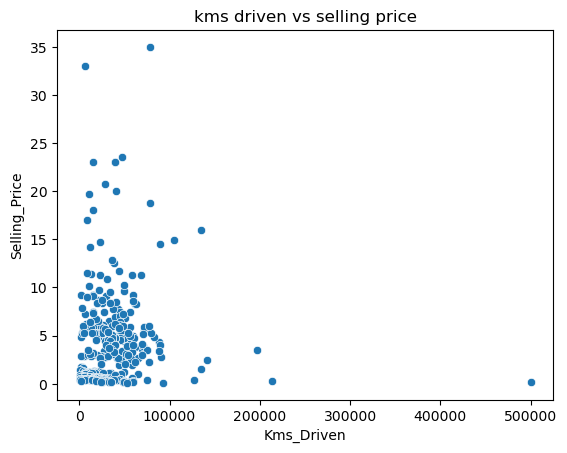

In [77]:
sns.scatterplot(x = 'Kms_Driven', y = 'Selling_Price', data = df)
plt.xlabel('Kms_Driven')
plt.ylabel('Selling_Price')
plt.title('kms driven vs selling price')
plt.show()

### Insights

1.more the km driven, less the price (inversly prop)
2.High Milage cars (Driven more) usually sold for less price
  Most cars are driven under 100000



### Trend Analysis
Average Selling Price by car Age


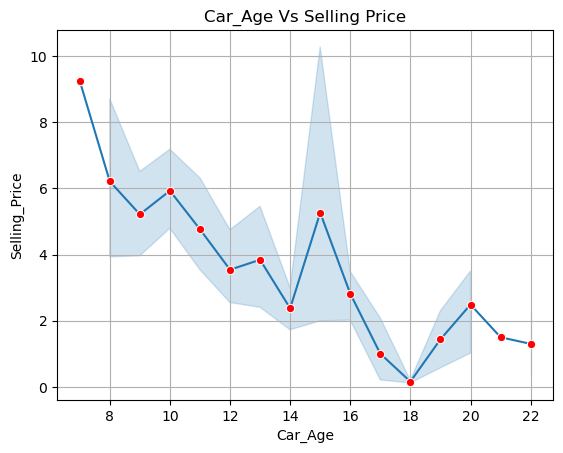

In [79]:
sns.lineplot(x = 'Car_Age', y = 'Selling_Price',data = df,marker = 'o',markerfacecolor = 'red')
plt.xlabel('Car_Age')
plt.ylabel('Selling_Price')
plt.title('Car_Age Vs Selling Price')
plt.grid(True)
plt.show()

### Insights:
 1. when the car is getting old, the selling price starts declining.
 2.It can be possible that there was some vehicles which was 18 years old and was a very bad condition.

# Fuel type by Selling price

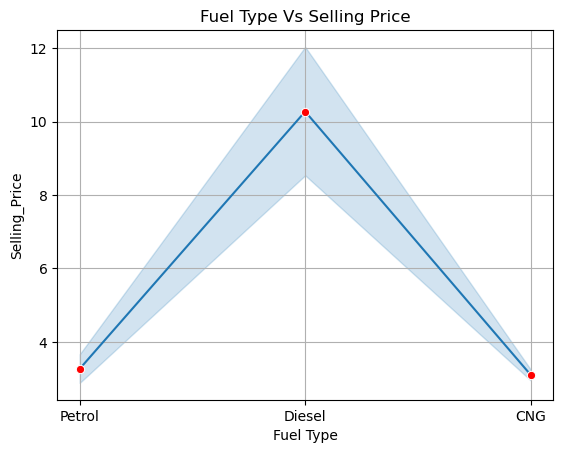

In [81]:
sns.lineplot(x = 'Fuel_Type', y = 'Selling_Price',data = df,marker = 'o',markerfacecolor = 'red')
plt.xlabel('Fuel Type')
plt.ylabel('Selling_Price')
plt.title('Fuel Type Vs Selling Price')
plt.grid(True)
plt.show()

### Insight:

1.Diesel cars are selling more as compared to Petrol and CNG (Diseal is cheaper than petrol and can be better for commute than CNG)
2.petrol has cars & bikes --> less avg price....... diesel has cars only --> more avg price....

### Value Depreciation Trend

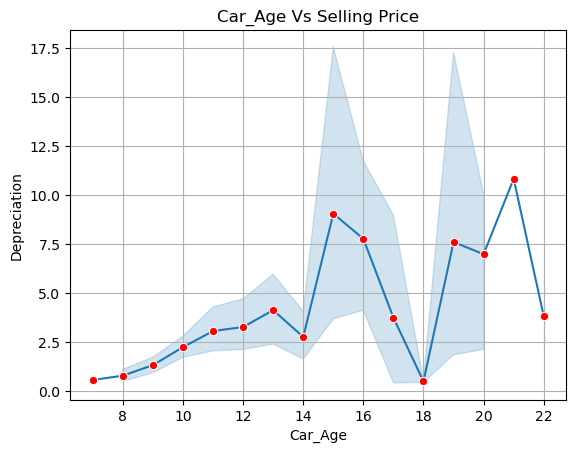

In [83]:
sns.lineplot(x = 'Car_Age', y = 'Depreciation',data = df,marker = 'o',markerfacecolor = 'red')
plt.xlabel('Car_Age')
plt.ylabel('Depreciation')
plt.title('Car_Age Vs Selling Price')
plt.grid(True)
plt.show()

### Insight:
The more the car will be old the more depreciation rate will increase. 

In [223]:
df.head(1)

,Brand,Year,Selling_Price,Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Depreciation,Car_Driven_Per_Year,Segment
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,2.24,2454.545455,Standard


In [85]:
summary = df.groupby('Fuel_Type')[['Selling_Price','Depreciation','Car_Driven_Per_Year']].mean()
summary

,Selling_Price,Depreciation,Car_Driven_Per_Year
Fuel_Type,,,
CNG,3.100000,3.315000,3560.642857
Diesel,10.278500,5.536000,4395.279595
Petrol,3.264184,2.319372,2688.809494


### insight

# Based on Selling price
Diseal cars have the highest average selling price
on average petrol cars are sold for 3 lac ruppees
# Based on Depreciation
Diseal car lose the most value over the time ( mostly car only)
Petrol has the least depreciation (Bike also)
# Based on km driven per year
Diesel cars are driven the most (4395 km/year)
Petrol car the least 2688 km/year

## Final Insights for fuel type vehicals

# Diesel : 
      More expensive, Depreciation is more, drive more -> can be better fot longer travel
# Petrol : 
      Petriol vehicals are cheaper, depreciate less, are used more freqent
# CNG :
     More Cost effective option -> because it lies in between Diesel and petrol

# Average depreciation rate

In [87]:
df['Depreciation_%'] = np.round((df['Depreciation'] / df['Price'])*100,2)
df

,Brand,Year,Selling_Price,Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Depreciation,Car_Driven_Per_Year,Segment,Depreciation_%
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,2.24,2454.545455,Standard,40.07
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,4.79,3583.333333,Standard,50.21
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,2.60,862.500000,Standard,26.40
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,1.30,371.428571,Standard,31.33
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,2.27,3859.090909,Standard,33.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,9,2.10,3776.444444,Standard,18.10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,10,1.90,6000.000000,Standard,32.20
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,16,7.65,5495.875000,Standard,69.55
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,8,1.00,1125.000000,Standard,8.00


In [231]:
avg_dep = np.mean(df['Depreciation_%'])
avg_dep

36.55455149501662

### on average the depreciation rate of a vehical is 37%

In [89]:
df['depPerYear'] = df['Depreciation_%'] / df['Car_Age']

df

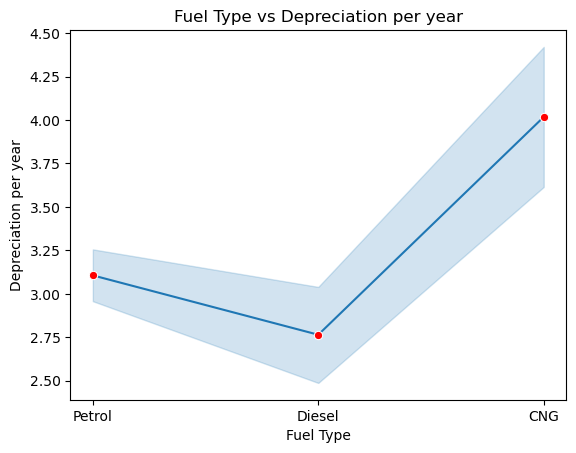

In [91]:
sns.lineplot(x=df['Fuel_Type'],y=df['depPerYear'],marker = 'o',markerfacecolor = 'red')
plt.xlabel('Fuel Type')
plt.ylabel('Depreciation per year')
plt.title('Fuel Type vs Depreciation per year')
plt.show()

### Insight

    Diesel vehical is having less depreciation per year as compared to Petrol and CNG.
    CNG has more depriciation because as the age increases, the risk of cng cylinder blasting increases.